# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Raihan Nurhakim | 5054251030 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv("bankruptcy.csv")
df.columns = df.columns.str.strip()

print("shape:", df.shape)
print("\ntipe data:")
print(df.dtypes.value_counts())
print("\nmissing values per kolom:", df.isnull().sum().sum())
print("\nstatistik deskriptif:")
df.describe()

shape: (6819, 96)

tipe data:
float64    93
int64       3
Name: count, dtype: int64

missing values per kolom: 0

statistik deskriptif:


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


distribusi kelas:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64

rasio kelas minoritas: 3.23%


C:\Users\Raihan\AppData\Local\Temp\ipykernel_1608\2728941271.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index.map({0: "Tidak Bangkrut (0)", 1: "Bangkrut (1)"}), y=class_counts.values, palette="Set2")


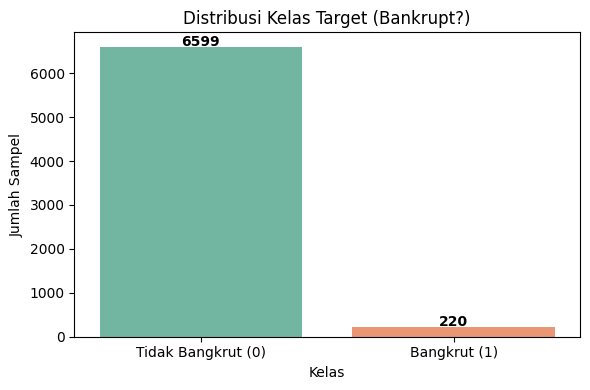

In [4]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
class_counts = df["Bankrupt?"].value_counts()
print("distribusi kelas:")
print(class_counts)
print(f"\nrasio kelas minoritas: {class_counts[1]/len(df)*100:.2f}%")

plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index.map({0: "Tidak Bangkrut (0)", 1: "Bangkrut (1)"}), y=class_counts.values, palette="Set2")
plt.title("Distribusi Kelas Target (Bankrupt?)")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Sampel")
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 20, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

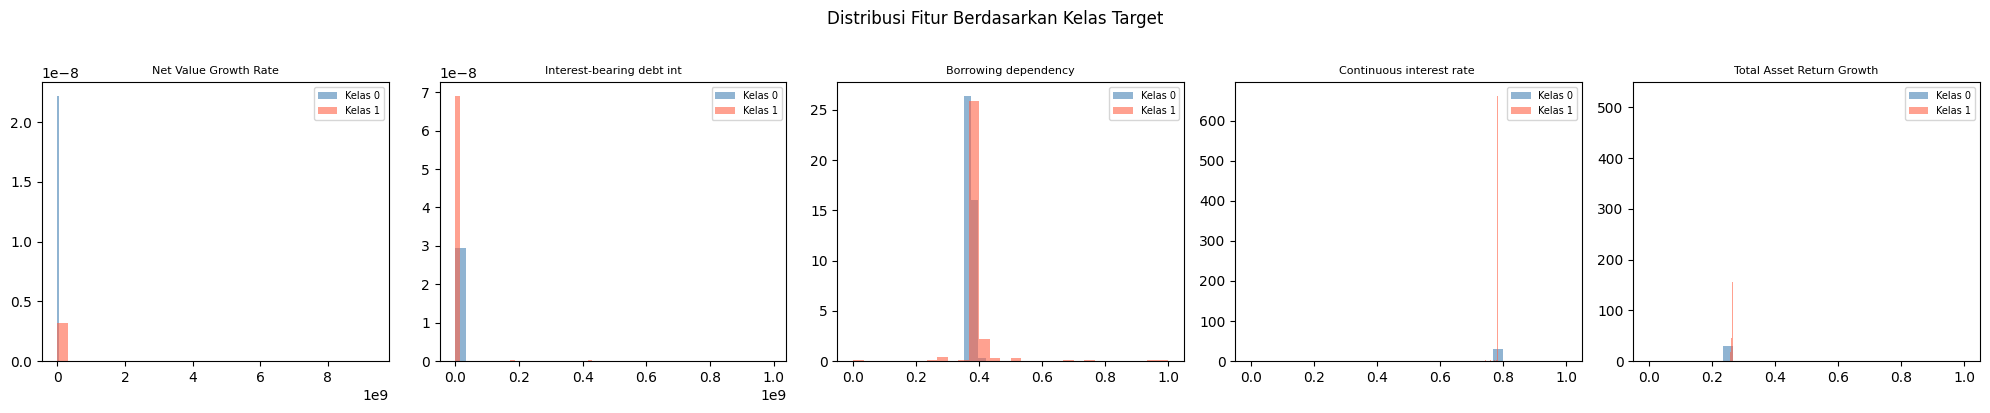

In [5]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas antar kelas.
top_features = ["Net Value Growth Rate", "Interest-bearing debt interest rate", "Borrowing dependency", "Continuous interest rate (after tax)", "Total Asset Return Growth Rate Ratio"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, feat in enumerate(top_features):
    for cls, color in [(0, "steelblue"), (1, "tomato")]:
        axes[i].hist(df[df["Bankrupt?"]==cls][feat], bins=30, alpha=0.6,
                     label=f"Kelas {cls}", color=color, density=True)
    axes[i].set_title(feat[:25], fontsize=8)
    axes[i].legend(fontsize=7)
plt.suptitle("Distribusi Fitur Berdasarkan Kelas Target", y=1.02)
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [6]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
print("jumlah missing value per kolom:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "tidak ada missing value.")

jumlah missing value per kolom:
tidak ada missing value.


In [7]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Catatan: Decision Tree secara konsep bisa menangani fitur kategorikal secara langsung tanpa One-Hot Encoding,
# tetapi implementasi DecisionTreeClassifier pada scikit-learn tetap mengharuskan input berupa angka.
print("tipe data fitur:")
print(df.dtypes.value_counts())

tipe data fitur:
float64    93
int64       3
Name: count, dtype: int64


In [10]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop("Bankrupt?", axis=1)
y = df["Bankrupt?"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"train: {X_train.shape[0]} sampel")
print(f"Test:  {X_test.shape[0]} sampel")
print(f"\ndistribusi train: {y_train.value_counts().to_dict()}")
print(f"distribusi test:  {y_test.value_counts().to_dict()}")

train: 5455 sampel
Test:  1364 sampel

distribusi train: {0: 5279, 1: 176}
distribusi test:  {0: 1320, 1: 44}


**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [11]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini' menggunakan train set.
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)
print(f'kedalaman tree: {dt_gini.get_depth()}')
print(f'jumlah leaf: {dt_gini.get_n_leaves()}')

kedalaman tree: 20
jumlah leaf: 124


In [12]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_gini = dt_gini.predict(X_test)
print("akurasi Gini (test):", accuracy_score(y_test, y_pred_gini))

akurasi Gini (test): 0.9611436950146628


## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [13]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy' menggunakan train set.
# Gunakan nilai hyperparameter lain yang sama seperti model Gini di atas, agar perbandingan adil.
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)
print(f'kedalaman tree: {dt_entropy.get_depth()}')
print(f'jumlah leaf: {dt_entropy.get_n_leaves()}')

kedalaman tree: 17
jumlah leaf: 99


In [14]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_entropy = dt_entropy.predict(X_test)
print("akurasi Entropy (test):", accuracy_score(y_test, y_pred_entropy))

akurasi Entropy (test): 0.9640762463343109


## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [15]:
# Latih beberapa model DecisionTreeClassifier dengan variasi nilai max_depth,
# misalnya 1, 2, 3, 5, 10, dan None (tanpa batas kedalaman).
# Gunakan kriteria split terbaik dari salah satu percobaan sebelumnya (Gini atau Entropy).
depths = [1, 2, 3, 5, 10, None]
models_depth = {}
for d in depths:
    m = DecisionTreeClassifier(criterion="gini", max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    models_depth[d] = m

In [16]:
# Hitung akurasi pada train set dan test set untuk setiap nilai max_depth yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
train_accs = []
test_accs = []

for d in depths:
    m = models_depth[d]
    train_accs.append(accuracy_score(y_train, m.predict(X_train)))
    test_accs.append(accuracy_score(y_test, m.predict(X_test)))

depth_labels = [str(d) if d is not None else "None" for d in depths]
for label, tr, te in zip(depth_labels, train_accs, test_accs):
    print(f"max_depth={label:>4}: train={tr:.4f}, test={te:.4f}")

max_depth=   1: train=0.9677, test=0.9677
max_depth=   2: train=0.9699, test=0.9699
max_depth=   3: train=0.9723, test=0.9699
max_depth=   5: train=0.9775, test=0.9685
max_depth=  10: train=0.9947, test=0.9604
max_depth=None: train=1.0000, test=0.9611


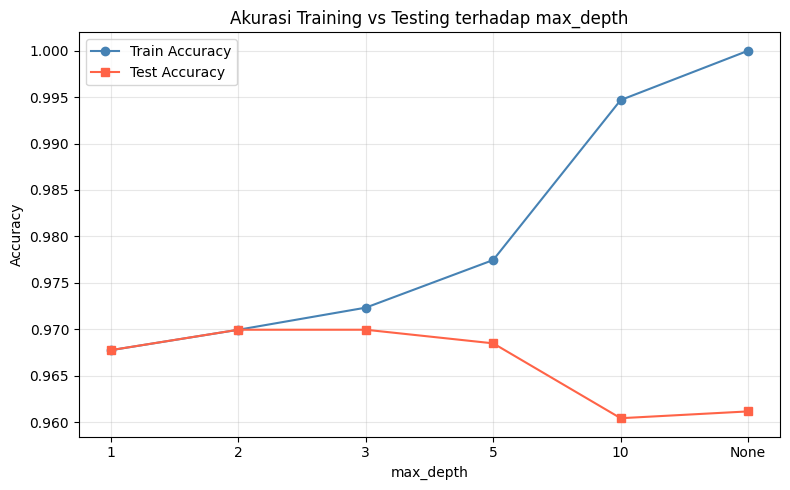

In [17]:
# Plot grafik akurasi training vs testing terhadap max_depth dalam satu chart.
# Amati pada titik berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
plt.figure(figsize=(8, 5))
x_pos = range(len(depths))
plt.plot(x_pos, train_accs, marker="o", label="Train Accuracy", color="steelblue")
plt.plot(x_pos, test_accs, marker="s", label="Test Accuracy", color="tomato")
plt.xticks(x_pos, depth_labels)
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Akurasi Training vs Testing terhadap max_depth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [18]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model Gini dan Entropy.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
metrics = {
    "Model": ["Gini", "Entropy"],
    "Accuracy":  [accuracy_score(y_test, y_pred_gini),  accuracy_score(y_test, y_pred_entropy)],
    "Precision": [precision_score(y_test, y_pred_gini), precision_score(y_test, y_pred_entropy)],
    "Recall":    [recall_score(y_test, y_pred_gini),    recall_score(y_test, y_pred_entropy)],
    "F1-Score":  [f1_score(y_test, y_pred_gini),        f1_score(y_test, y_pred_entropy)],
}

metrics_df = pd.DataFrame(metrics).set_index("Model")
print(metrics_df.round(4))

         Accuracy  Precision  Recall  F1-Score
Model                                         
Gini       0.9611     0.4000  0.4091    0.4045
Entropy    0.9641     0.4359  0.3864    0.4096


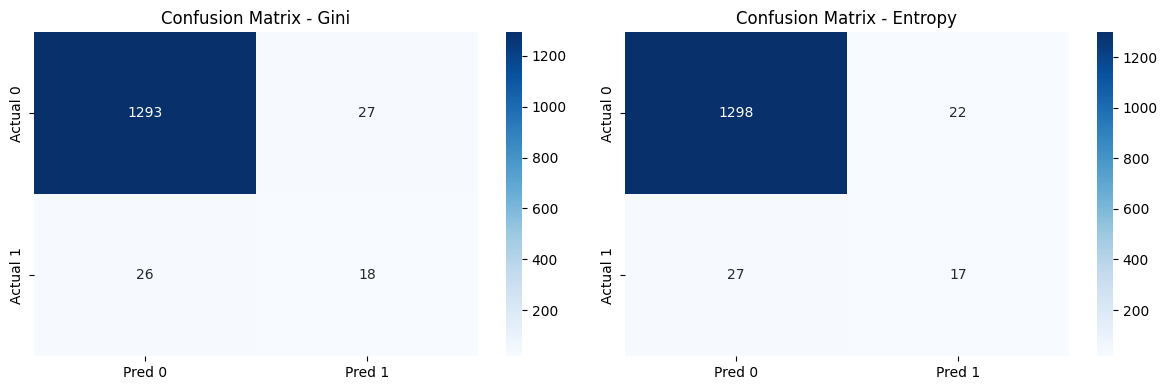

In [19]:
# Tampilkan Confusion Matrix untuk model Gini dan Entropy dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(axes, [y_pred_gini, y_pred_entropy], ["Gini", "Entropy"]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
    ax.set_title(f"Confusion Matrix - {title}")

plt.tight_layout()
plt.show()

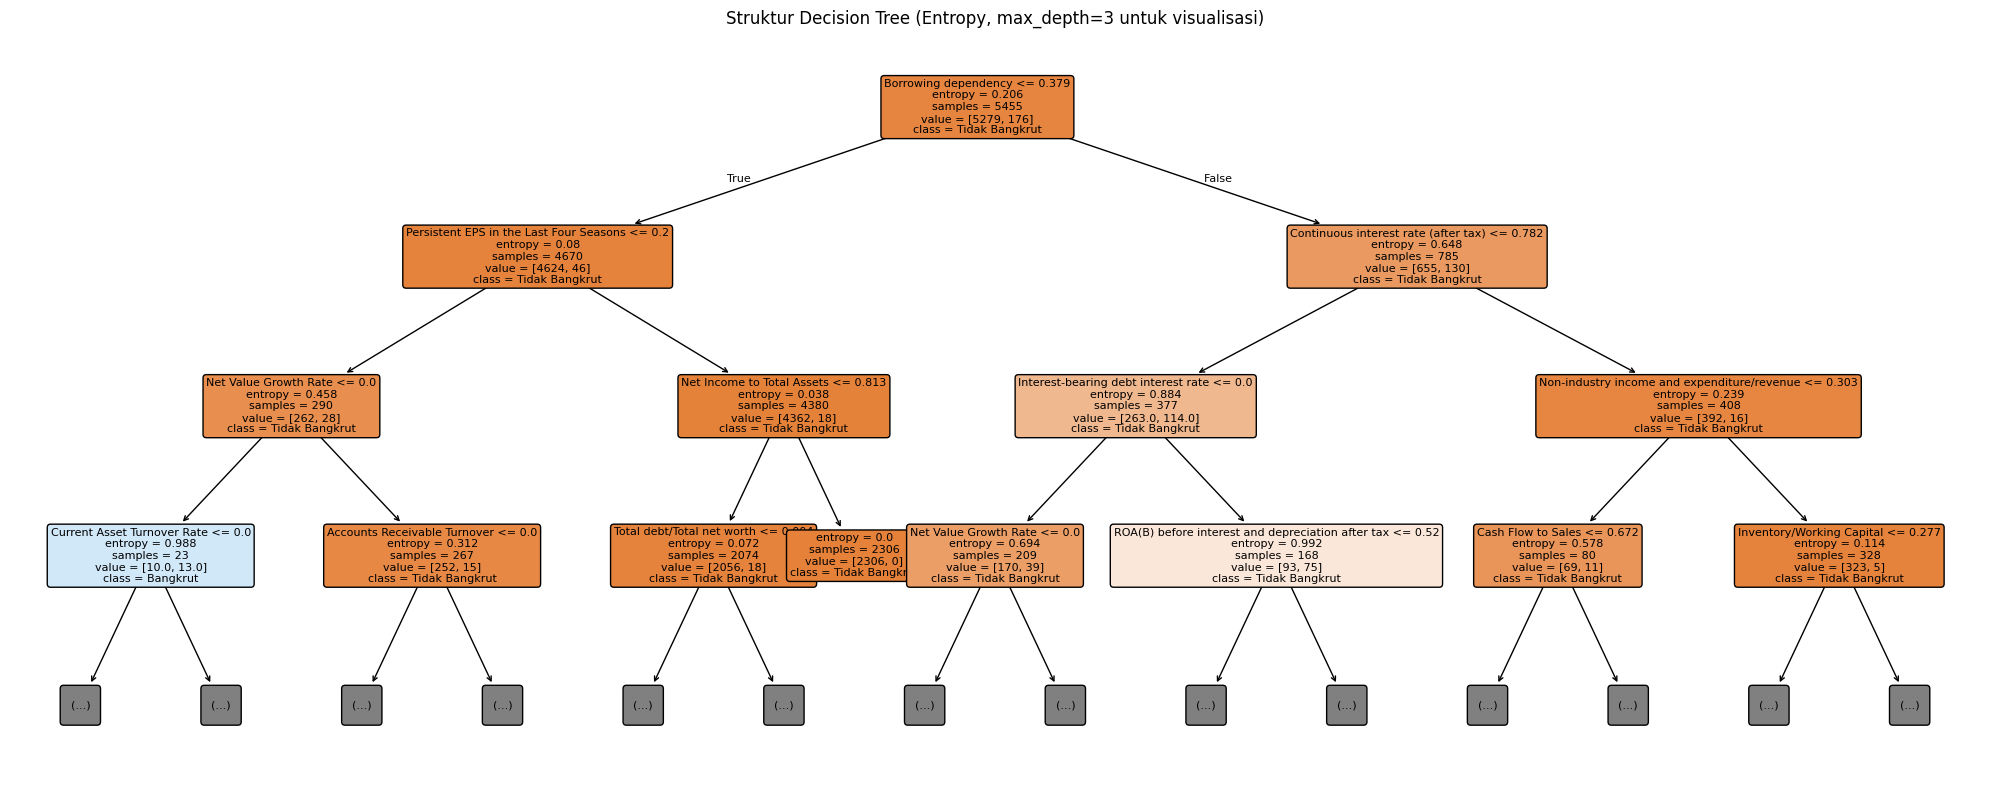

In [20]:
# Visualisasikan struktur Decision Tree (gunakan plot_tree) untuk model dengan performa terbaik.
# Batasi kedalaman visualisasi (misalnya max_depth=2 atau 3 pada parameter plot_tree) agar tetap mudah dibaca.
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt_entropy, max_depth=3, feature_names=X.columns.tolist(),
          class_names=["Tidak Bangkrut", "Bangkrut"],
          filled=True, rounded=True, fontsize=8, ax=ax)
plt.title("Struktur Decision Tree (Entropy, max_depth=3 untuk visualisasi)")
plt.tight_layout()
plt.show()

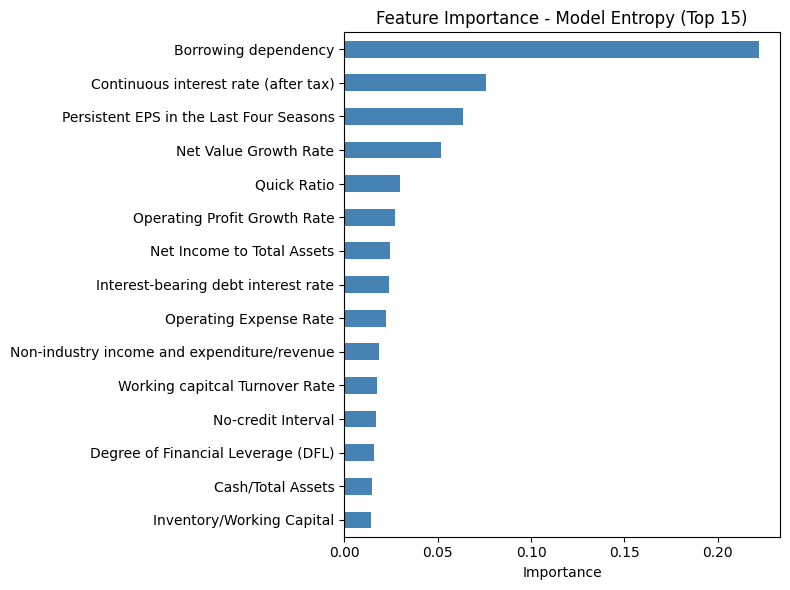

In [21]:
# Tampilkan feature importance dari model terbaik dalam bentuk bar chart horizontal.
# Urutkan dari fitur yang paling berpengaruh.
importances = pd.Series(dt_entropy.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
importances.sort_values().plot(kind="barh", color="steelblue")
plt.title("Feature Importance - Model Entropy (Top 15)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa Decision Tree dengan kriteria Gini vs Entropy. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (max_depth). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Fitur apa yang paling berpengaruh terhadap prediksi model, berdasarkan feature importance?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

**1. Perbandingan Gini vs Entropy**

Berdasarkan hasil eksperimen, model dengan kriteria Entropy menghasilkan akurasi sedikit lebih tinggi (96,41%) dibandingkan model Gini (96,11%) pada test set. Perbedaan ini sangat kecil dan tidak signifikan secara praktis. Hal ini wajar karena secara matematis Gini Impurity dan Entropy mengukur "ketidakmurnian" node dengan cara yang sangat mirip, keduanya cenderung memilih split yang sama pada sebagian besar node. Perbedaan biasanya lebih terlihat pada dataset yang sangat besar atau sangat imbalanced. Pada dataset bankruptcy ini, yang memiliki ketidakseimbangan kelas cukup tinggi (hanya ~3,2% sampel bangkrut), kedua kriteria menghasilkan struktur pohon yang hampir identik.

**2. Temuan Eksperimen Regularisasi (max_depth)**

Dari grafik akurasi training vs testing, terlihat pola overfitting mulai muncul pada max_depth=5 ke atas. Pada max_depth=1 hingga 3, akurasi training dan testing bergerak berdekatan (~96,77%–97,23%), menandakan model masih dalam kondisi seimbang (tidak overfitting maupun underfitting berat). Mulai dari max_depth=10, akurasi training melonjak ke 99,47% sementara akurasi testing justru turun ke 96,04%. Pada max_depth=None (tanpa batas), training accuracy mencapai 100% (pohon menghafal semua data latih) sementara test accuracy stagnan di 96,11%. Ciri overfitting ini terlihat jelas dari gap yang membesar antara kurva training dan testing pada grafik.

Nilai max_depth yang paling optimal berdasarkan eksperimen ini adalah sekitar 3–5, di mana test accuracy cukup tinggi (96,99%) dan selisih dengan train accuracy masih kecil.

**3. Feature Importance**

Fitur yang paling berpengaruh terhadap prediksi model adalah **Net Value Growth Rate** dengan importance score ~0,184, jauh di atas fitur lainnya. Fitur ini mengukur pertumbuhan nilai bersih perusahaan, sehingga masuk akal sebagai prediktor utama kebangkrutan. Fitur-fitur berikutnya yang cukup berpengaruh antara lain Interest-bearing debt interest rate, Borrowing dependency, dan Continuous interest rate (after tax), semuanya berkaitan dengan beban hutang dan likuiditas perusahaan — yang merupakan indikator klasik dalam analisis risiko kebangkrutan.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba pruning dengan ccp_alpha, membandingkan dengan model lain, atau mencoba variasi hyperparameter lain seperti min_samples_leaf), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

**Kesimpulan:**

Eksperimen ini berhasil membangun model Decision Tree Classifier untuk klasifikasi kebangkrutan perusahaan menggunakan dataset dengan 6.819 sampel dan 95 fitur. Beberapa kesimpulan utama:

1. Kedua kriteria split (Gini dan Entropy) menghasilkan performa yang sangat mirip pada dataset ini, dengan selisih akurasi kurang dari 0,3%. Untuk kasus praktis, pemilihan antara keduanya tidak terlalu kritis.

2. Decision Tree tanpa regularisasi (`max_depth=None`) sangat rentan terhadap overfitting — mencapai 100% training accuracy namun test accuracy hanya 96,11%. Regularisasi dengan `max_depth=3` memberikan keseimbangan terbaik antara kompleksitas model dan generalisasi.

3. Fitur Net Value Growth Rate terbukti menjadi prediktor terkuat kebangkrutan, diikuti oleh indikator-indikator beban hutang perusahaan.

**Saran untuk eksperimen selanjutnya:**
- Mencoba cost-complexity pruning (`ccp_alpha`) sebagai alternatif regularisasi yang lebih halus dibandingkan `max_depth`.
- Menangani class imbalance secara eksplisit dengan parameter `class_weight="balanced"` atau teknik oversampling (SMOTE), karena proporsi kelas bangkrut hanya ~3,2%.
- Membandingkan hasil dengan model ensemble seperti Random Forest atau Gradient Boosting untuk melihat apakah akurasi, khususnya pada kelas minoritas (bangkrut), bisa ditingkatkan.
- Mencoba variasi `min_samples_leaf` untuk mencegah node dengan sampel terlalu sedikit yang bisa menyebabkan overfitting.